# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/PundarikakshNTripathi/FlyRankAI-ML-Internship/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

**Top K Action Plan:**
1. `decaying_high_volume`: Model probability > 0.65 AND impressions > 1000. Action: Full Refresh / Expansion.
2. `stale_mid_tier`: Model probability > 0.50 AND age > 365. Action: Metadata/Content verification.

## 2. Intended use and limits

**Intended Use:** Decision support queue for SEO editors.

**Limits:** Do not use this to automatically redirect or delete pages. The model identifies risk, it does not confirm content accuracy.

## 3. Human review + the no-go list

**Human Verification:** The editor must check if the drop is due to seasonality (e.g., 'Christmas gifts' dropping in January) before acting.

**No-Go:** Automated canonicalization or deletion without human sign-off.

## 4. Monitoring / retrain triggers

Triggers for retraining: A major Google core update shifts base CTR distributions globally, rendering the historical tree thresholds inaccurate.

## 5. Exports for the paper

Exporting the final ranked CSV.

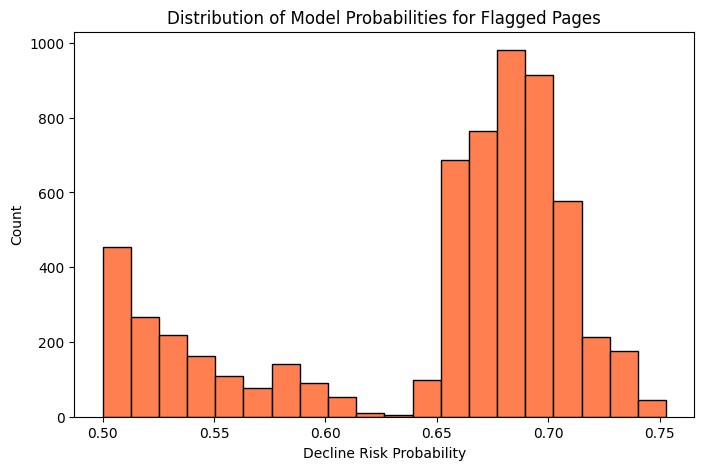

Artifacts exported. Total actionable pages found: 6046


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os
from sklearn.ensemble import RandomForestClassifier

data_path = '../../data/raw/content_refresh_anonymized.csv'
if not os.path.exists(data_path):
    data_path = 'data/raw/content_refresh_anonymized.csv'

df = pd.read_csv(data_path)

# Train the model on the full dataset to generate final scores
features = ['impressions_90d', 'sessions_90d', 'content_age_days', 'days_since_last_update', 'word_count', 'ctr', 'avg_position', 'engagement_rate']
df[features] = df[features].fillna(0)
df['is_declining'] = (df['trend_direction'] == 'down').astype(int)

X = df[features]
y = df['is_declining']

rf = RandomForestClassifier(n_estimators=100, max_depth=6, random_state=42)
rf.fit(X, y)

df['model_probability'] = rf.predict_proba(X)[:, 1]

# Apply reason codes based on the markdown playbook
df['recommended_action'] = 'Monitor'
df['reason_code'] = 'none'

# Rule 1: decaying_high_volume
mask1 = (df['model_probability'] > 0.65) & (df['impressions_90d'] > 1000)
df.loc[mask1, 'recommended_action'] = 'Full Refresh / Expansion'
df.loc[mask1, 'reason_code'] = 'decaying_high_volume'

# Rule 2: stale_mid_tier
mask2 = (df['model_probability'] > 0.50) & (df['model_probability'] <= 0.65) & (df['content_age_days'] > 365)
df.loc[mask2, 'recommended_action'] = 'Metadata / Content Verification'
df.loc[mask2, 'reason_code'] = 'stale_mid_tier'

# Filter and sort final queue
final_queue = df[df['reason_code'] != 'none'].sort_values('model_probability', ascending=False).copy()

out_dir = '../../outputs'
if not os.path.exists('../../outputs') and os.path.exists('outputs'):
    out_dir = 'outputs'
os.makedirs(out_dir, exist_ok=True)

final_queue[['client_id', 'content_id', 'model_probability', 'recommended_action', 'reason_code']].head(100).to_csv(f'{out_dir}/final_action_playbook.csv', index=False)

# Plot chart
plt.figure(figsize=(8, 5))
plt.hist(final_queue['model_probability'], bins=20, color='coral', edgecolor='black')
plt.title('Distribution of Model Probabilities for Flagged Pages')
plt.xlabel('Decline Risk Probability')
plt.ylabel('Count')
os.makedirs(f'{out_dir}/charts', exist_ok=True)
plt.savefig(f'{out_dir}/charts/playbook_score_dist.png')
plt.show()
print(f"Artifacts exported. Total actionable pages found: {len(final_queue)}")


## Self-check

Before you submit, confirm each line honestly:

- [x] Every section above is filled — markdown thinking AND the code that backs it
- [x] The notebook runs top to bottom with no errors (Runtime → Run all)
- [x] No client names, URLs, or private queries anywhere
- [x] My claims use careful words: observed, measured, directional, decision-support
- [x] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.